In [1]:
"""
stage2_hawkes.py -- Stage 2 (+3): discrete-time logistic Hawkes (notebook version).

RULES
  S2.1  p_t = P(is_target[t] | info <= t-1). Event-count features use event_bar
        in lag bins with min lag 1; age/tod computed from info <= t-1 (S2.3).
  S2.2  Lag bins (lo, hi) inclusive from bin_edges: (1,2,3,5,...) ->
        [1,1],[2,2],[3,3],[4,5],...
  S2.3  age(t) = t - (last target bar strictly before t), session-local;
        no prior target -> age = local_t + 1. Never reads is_target[t].
  S2.4  All features are within-session => session-date splits need no embargo.
  S2.5  pcont(t, H) = prod_{h=1..H} (1 - p_{t+h}) with the event set frozen at
        <= t (counterfactual: no new oscillator or target events after t).
        Truncated at session end; h_used reported. pbreak = 1 - pcont.
  S2.6  Exogenous events with opposing == 0 dropped; TICK_HMA dropped.
  S2.7  Warm bars excluded from fit, predict and pcont query points.
  S2.8  Plain L2 logistic regression (lbfgs), no class weighting.
  S2.9  bootstrap=N: session-level resampling with replacement, percentile CIs
        on kernel coefficients.
  S2.10 tod bins read raw hour*60+minute against TOD_START_MIN / TOD_BIN_MIN /
        N_TOD. No tz handling: timestamps must already be session-local and the
        constants must match the session template -- verify at data prep.
"""

import json
import numpy as np
import pandas as pd
import joblib
from sklearn.metrics import log_loss, roc_auc_score
from sklearn.linear_model import LogisticRegression

TOD_START_MIN = 570      # first session minute (9:30)
TOD_BIN_MIN = 30
N_TOD = 13               # bins covering the session 6.5hrs / 30 min

HORIZON = 8

FRAME=6
OUT_DIR='data/stage-2'

STREAMS = ["MNQ_D1", "MNQ_D2", "TICK_D1", "TICK_D2"]

In [2]:
def _make_classes():
    cls = []
    for s in STREAMS:
        cls.append((s, "opp"))
        cls.append((s, "conf"))
    cls.append(("MNQ_JMA_SELF", "all"))
    return cls

def _bins_from_edges(edges):
    bins, lo = [], 1
    for e in edges:
        bins.append((lo, int(e)))
        lo = int(e) + 1
    return bins

def _age_bins_from_edges(edges):
    b = _bins_from_edges(edges)
    b.append((int(edges[-1]) + 1, 10 ** 9))
    return b

class Featurizer:
    def __init__(self, bars, events,
                 bin_edges=(1, 2, 3, 5, 8, 13, 21, 34),
                 age_edges=(1, 2, 3, 5, 8, 13, 21, 34, 55, 89)):
        self.bin_edges = list(bin_edges)
        self.age_edges = list(age_edges)
        self.bins = _bins_from_edges(bin_edges)
        self.age_bins = _age_bins_from_edges(age_edges)
        self.classes = _make_classes()
        self.feature_names = (
            [f"{s}|{c}|lag{lo}_{hi}" for (s, c) in self.classes for (lo, hi) in self.bins]
            + [f"age|{lo}_{hi}" for (lo, hi) in self.age_bins]
            + [f"tod|{k}" for k in range(N_TOD)]
        )
        self.n_feat = len(self.feature_names)

        ev = events[events["stream"].isin([c[0] for c in self.classes])]
        ev = ev[~((ev["stream"] != "MNQ_JMA_SELF") & (ev["opposing"] == 0))]   # S2.6
        evg = dict(tuple(ev.groupby("date")))

        self.sessions = []
        bars = bars.sort_values("bar_index").reset_index(drop=True)
        for sess, g in bars.groupby("date", sort=True):
            n = len(g)
            first = int(g["bar_index"].iloc[0])
            tgt = g["is_target"].to_numpy()
            warm = g["warm"].to_numpy()
            ts = pd.DatetimeIndex(g["timestamp"])
            mins = ts.hour.to_numpy() * 60 + ts.minute.to_numpy() - TOD_START_MIN   # S2.10
            tod = np.clip(mins // TOD_BIN_MIN, 0, N_TOD - 1).astype(np.int16)
            lt_incl = np.maximum.accumulate(np.where(tgt, np.arange(n), -1))
            P = {}
            e = evg.get(sess)
            for (s, c) in self.classes:
                if e is None:
                    loc = np.empty(0, np.int64)
                else:
                    if s == "MNQ_JMA_SELF":
                        sub = e[e["stream"] == s]
                    else:
                        want = 1 if c == "opp" else -1
                        sub = e[(e["stream"] == s) & (e["opposing"] == want)]
                    loc = sub["event_bar"].to_numpy() - first
                ind = np.zeros(n, np.int32)
                ind[loc] = 1
                P[(s, c)] = np.concatenate(([0], np.cumsum(ind)))              # P[i] = count pos < i
            self.sessions.append(dict(
                sess=sess, first=first, n=n, tgt=tgt, warm=warm, tod=tod,
                lt_incl=lt_incl, P=P,
                bar_index=g["bar_index"].to_numpy(),
                timestamp=g["timestamp"].to_numpy()))

    def _fill(self, S, t, out):
        n = S["n"]
        col = 0
        for c in self.classes:
            P = S["P"][c]
            for (lo, hi) in self.bins:                                         # S2.1, S2.2
                b = np.clip(t - lo + 1, 0, n)
                a = np.clip(t - hi, 0, n)
                out[:, col] = P[b] - P[a]
                col += 1
        lt = np.where(t > 0, S["lt_incl"][np.maximum(t - 1, 0)], -1)           # S2.3
        age = np.where(lt >= 0, t - lt, t + 1)
        for (lo, hi) in self.age_bins:
            out[:, col] = (age >= lo) & (age <= hi)
            col += 1
        tod = S["tod"][t]
        for k in range(N_TOD):
            out[:, col] = tod == k
            col += 1

    def _fill_frozen(self, S, q, h, out):
        """S2.5: features at t = q+h using only events/targets with pos <= q."""
        n = S["n"]
        t = q + h
        cap = q + 1
        col = 0
        for c in self.classes:
            P = S["P"][c]
            for (lo, hi) in self.bins:
                b = np.clip(np.minimum(t - lo + 1, cap), 0, n)
                a = np.clip(np.minimum(t - hi, cap), 0, n)
                out[:, col] = P[b] - P[a]
                col += 1
        lt = S["lt_incl"][q]
        age = np.where(lt >= 0, t - lt, t + 1)
        for (lo, hi) in self.age_bins:
            out[:, col] = (age >= lo) & (age <= hi)
            col += 1
        tod = S["tod"][np.minimum(t, n - 1)]
        for k in range(N_TOD):
            out[:, col] = tod == k
            col += 1

    def _selected(self, date_from, date_to):
        for S in self.sessions:
            d = str(S["sess"])
            if date_from is not None and d < date_from:
                continue
            if date_to is not None and d > date_to:
                continue
            yield S

    def build(self, date_from=None, date_to=None):
        sel = []
        total = 0
        for S in self._selected(date_from, date_to):
            t = np.nonzero(~S["warm"])[0]                                      # S2.7
            sel.append((S, t))
            total += len(t)
        X = np.zeros((total, self.n_feat), np.float32)
        y = np.zeros(total, np.int8)
        bar_index = np.zeros(total, np.int64)
        sess_id = np.zeros(total, np.int32)
        timestamp = np.zeros(total, "datetime64[ns]")
        ofs = 0
        for sid, (S, t) in enumerate(sel):
            m = len(t)
            self._fill(S, t, X[ofs:ofs + m])
            y[ofs:ofs + m] = S["tgt"][t]
            bar_index[ofs:ofs + m] = S["bar_index"][t]
            sess_id[ofs:ofs + m] = sid
            timestamp[ofs:ofs + m] = S["timestamp"][t]
            ofs += m
        meta = pd.DataFrame({"bar_index": bar_index, "timestamp": timestamp,
                             "sess_id": sess_id, "is_target": y.astype(bool)})
        return X, y, meta

In [3]:
def fit_hawkes(fz, train_start=None, train_end=None, c=100.0, bootstrap=0,
               out_dir=None):
    X, y, meta = fz.build(train_start, train_end)
    model = LogisticRegression(C=c, solver="lbfgs", max_iter=2000)             # S2.8
    model.fit(X, y)
    p = model.predict_proba(X)[:, 1]
    eps = 1e-12
    ll = -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))
    r = y.mean()
    ll_const = -(r * np.log(r) + (1 - r) * np.log(1 - r))

    bundle = dict(model=model, feature_names=fz.feature_names,
                  bin_edges=fz.bin_edges, age_edges=fz.age_edges, c=c,
                  train_start=train_start, train_end=train_end)

    coef = model.coef_[0]
    kern = pd.DataFrame({"feature": fz.feature_names, "coef": coef})
    kern["group"] = kern["feature"].str.split("|").str[0]
    kern["cls"] = kern["feature"].str.split("|").str[1]

    if bootstrap > 0:                                                          # S2.9
        rng = np.random.default_rng(7)
        sids = np.unique(meta["sess_id"].to_numpy())
        sid_arr = meta["sess_id"].to_numpy()
        rows_by_sid = {s: np.nonzero(sid_arr == s)[0] for s in sids}
        coefs = np.zeros((bootstrap, fz.n_feat))
        for b in range(bootstrap):
            pick = rng.choice(sids, size=len(sids), replace=True)
            rows = np.concatenate([rows_by_sid[s] for s in pick])
            mb = LogisticRegression(C=c, solver="lbfgs", max_iter=2000)
            mb.fit(X[rows], y[rows])
            coefs[b] = mb.coef_[0]
        kern["coef_lo"] = np.percentile(coefs, 2.5, axis=0)
        kern["coef_hi"] = np.percentile(coefs, 97.5, axis=0)

    bundle["kernels"] = kern
    if out_dir is not None:
        joblib.dump(bundle, f"{out_dir}/hawkes_model.joblib")
        kern.to_csv(f"{out_dir}/kernels.csv", index=False)

    summary = dict(n_rows=int(len(y)), n_targets=int(y.sum()),
                   base_rate=float(r), logloss_insample=float(ll),
                   logloss_const=float(ll_const),
                   intercept=float(model.intercept_[0]), n_features=fz.n_feat)
    print(json.dumps(summary, indent=2))
    return bundle

def predict_hawkes(fz, bundle, start=None, end=None, out_file=None):
    X, y, meta = fz.build(start, end)
    meta = meta.drop(columns=["sess_id"]).copy()
    meta["p"] = bundle["model"].predict_proba(X)[:, 1]
    if out_file is not None:
        meta.to_parquet(out_file, index=False)
    return meta

def pcont_hawkes(fz, bundle, at_bar_index, horizon=HORIZON, out_file=None):
    model = bundle["model"]
    want = np.sort(np.asarray(at_bar_index, dtype=np.int64))

    out_bar, out_pc, out_hu = [], [], []
    out_ts = []
    
    for S in fz.sessions:
        lo, hi = S["bar_index"][0], S["bar_index"][-1]
        w = want[(want >= lo) & (want <= hi)]
        if len(w) == 0:
            continue
        q = w - S["first"]
        q = q[~S["warm"][q]]                                                   # S2.7
        if len(q) == 0:
            continue
        n = S["n"]
        logsurv = np.zeros(len(q))
        h_used = np.zeros(len(q), np.int32)
        buf = np.zeros((len(q), fz.n_feat), np.float32)
        for h in range(1, horizon + 1):
            valid = q + h <= n - 1
            if not valid.any():
                break
            iv = np.nonzero(valid)[0]
            sub = buf[:len(iv)]
            fz._fill_frozen(S, q[iv], h, sub)                                  # S2.5
            p = model.predict_proba(sub)[:, 1]
            logsurv[iv] += np.log1p(-p)
            h_used[iv] += 1
        out_bar.append(q + S["first"])
        out_ts.append(S["timestamp"][q])        
        out_pc.append(np.exp(logsurv))
        out_hu.append(h_used)

    res = pd.DataFrame({"bar_index": np.concatenate(out_bar),
                        "timestamp": np.concatenate(out_ts),                        
                        "pcont": np.concatenate(out_pc),
                        "h_used": np.concatenate(out_hu)})
    res["pbreak"] = 1.0 - res["pcont"]
    res["H"] = horizon
    if out_file is not None:
        res.to_parquet(out_file, index=False)
    return res

def plot_kernels(fz, bundle, out_path=None):
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    coef = bundle["model"].coef_[0]
    ks = fz.classes
    nc = 3
    nr = (len(ks) + nc - 1) // nc
    fig = make_subplots(rows=nr, cols=nc, subplot_titles=[f"{s}|{c}" for (s, c) in ks])
    centers = [0.5 * (lo + hi) for (lo, hi) in fz.bins]
    nb = len(fz.bins)
    for i, (s, c) in enumerate(ks):
        r, cix = i // nc + 1, i % nc + 1
        w = coef[i * nb:(i + 1) * nb]
        fig.add_trace(go.Scatter(x=centers, y=w, mode="lines+markers",
                                 line_shape="hv", showlegend=False), row=r, col=cix)
        fig.add_trace(go.Scatter(x=[centers[0], centers[-1]], y=[0, 0], mode="lines",
                                 line=dict(color="black", dash="dot", width=1),
                                 showlegend=False), row=r, col=cix)
    fig.update_layout(height=320 * nr, width=1400, title="Fitted kernels (logit weight vs lag)")
    if out_path is not None:
        fig.write_html(out_path)
    fig.show()
    return fig

In [4]:
bars = pd.read_parquet(f'data/stage-0/bars_{FRAME}s.parquet')
events = pd.read_parquet(f'data/stage-0/events_{FRAME}s.parquet')

fz = Featurizer(bars, events, bin_edges=(1, 2, 3, 5, 8, 13, 21, 34), age_edges=(1, 2, 3, 5, 8, 13, 21, 34, 55, 89))

In [5]:
# fit + holdout metrics

bundle = fit_hawkes(fz, train_end="2024-12-31", out_dir=OUT_DIR)
pred = predict_hawkes(fz, bundle, start="2025-01-01", out_file=f"{OUT_DIR}/meta-{HORIZON}h.parquet")          # bar_index, timestamp, is_target, p

y, p = pred.is_target.to_numpy(), pred.p.to_numpy()
print("holdout logloss", log_loss(y, p))
print("const logloss  ", log_loss(y, np.full_like(p, y.mean())))
print("holdout auc    ", roc_auc_score(y, p))

pred.assign(bin=pd.qcut(pred.p, 10)).groupby("bin", observed=True).agg(mean_p=("p", "mean"), realized=("is_target", "mean"), n=("p", "size"))   # calibration

{
  "n_rows": 2958187,
  "n_targets": 304987,
  "base_rate": 0.10309929696804157,
  "logloss_insample": 0.3047608733177185,
  "logloss_const": 0.33183994267976835,
  "intercept": -2.7088775634765625,
  "n_features": 96
}
holdout logloss 0.30467721819877625
const logloss   0.3313855826854706
holdout auc     0.714158689527672


,mean_p,realized,n
bin,,,
"(-0.000887, 0.023]",0.014207,0.023256,148819
"(0.023, 0.0385]",0.031122,0.035083,148818
"(0.0385, 0.0509]",0.044890,0.037159,148818
"(0.0509, 0.064]",0.057196,0.038403,148818
"(0.064, 0.0833]",0.072747,0.047864,148818
"(0.0833, 0.115]",0.098571,0.101365,148818
"(0.115, 0.145]",0.130365,0.163361,148818
"(0.145, 0.172]",0.158395,0.179562,148818
"(0.172, 0.204]",0.186658,0.193928,148818


In [6]:
# ablations: age+tod-only (the bar to clear) and drop-TICK (cross-instrument marginal)

Xtr, ytr, _ = fz.build(None, "2024-12-31")
Xte, yte, _ = fz.build("2025-01-01", None)
names = fz.feature_names

def run(keep):
    ci = [i for i, n in enumerate(names) if keep(n)]
    m = LogisticRegression(C=100.0, solver="lbfgs", max_iter=2000).fit(Xtr[:, ci], ytr)
    return log_loss(yte, m.predict_proba(Xte[:, ci])[:, 1])

print("age+tod only ", run(lambda n: n.startswith(("age|", "tod|"))))
print("no TICK      ", run(lambda n: not n.startswith("TICK")))
print("full         ", run(lambda n: True))

age+tod only  0.32565784454345703
no TICK       0.3059399425983429
full          0.30467721819877625


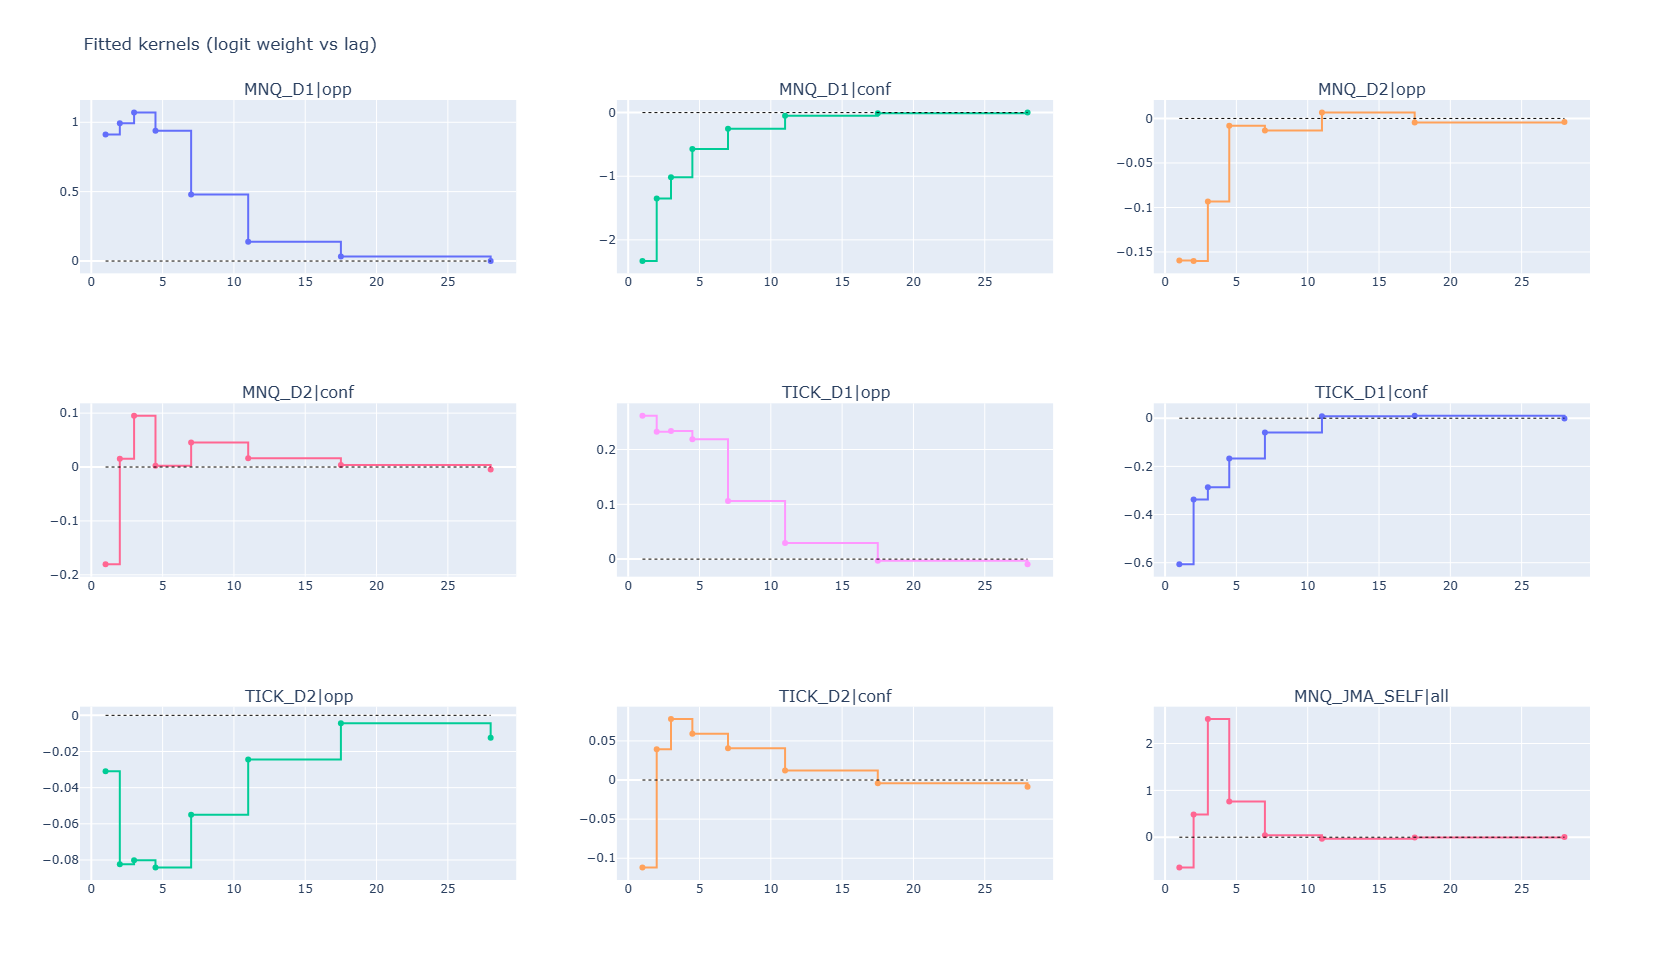

In [7]:
fig = plot_kernels(fz, bundle, out_path=f"{OUT_DIR}/kernels-{HORIZON}h.html")

In [8]:
# event-triggered Pbreak at opposing pivots in the holdout, vs realized
opp_h = events[(events.opposing == 1) & (events['date'].astype(str) >= "2025-01-01")]
at = np.unique(opp_h.event_bar.to_numpy())
res = pcont_hawkes(fz, bundle, at, horizon=HORIZON,out_file=f"{OUT_DIR}/results-{HORIZON}h.parquet")
ev_p = opp_h.merge(res[["bar_index", "pbreak", "h_used"]], left_on="event_bar", right_on="bar_index")

tgt = np.sort(bars.loc[bars.is_target, "bar_index"].to_numpy())
a = np.searchsorted(tgt, ev_p.event_bar + 1, "left")
b = np.searchsorted(tgt, ev_p.event_bar + HORIZON, "right")
ev_p["broke8"] = b > a
ev_p.assign(bin=pd.qcut(ev_p.pbreak, 10)).groupby("bin", observed=True).agg(
    mean_pbreak=("pbreak", "mean"), realized=("broke8", "mean"), n=("pbreak", "size"))

,mean_pbreak,realized,n
bin,,,
"(-0.001, 0.419]",0.370344,0.597681,83573
"(0.419, 0.478]",0.449566,0.608881,83573
"(0.478, 0.545]",0.508470,0.615577,83572
"(0.545, 0.662]",0.601444,0.702643,83573
"(0.662, 0.719]",0.695309,0.726850,83573
"(0.719, 0.747]",0.733998,0.726846,83572
"(0.747, 0.769]",0.758415,0.722573,83575
"(0.769, 0.789]",0.779144,0.725942,83570
"(0.789, 0.813]",0.800622,0.716737,83576


In [9]:
## follow ups

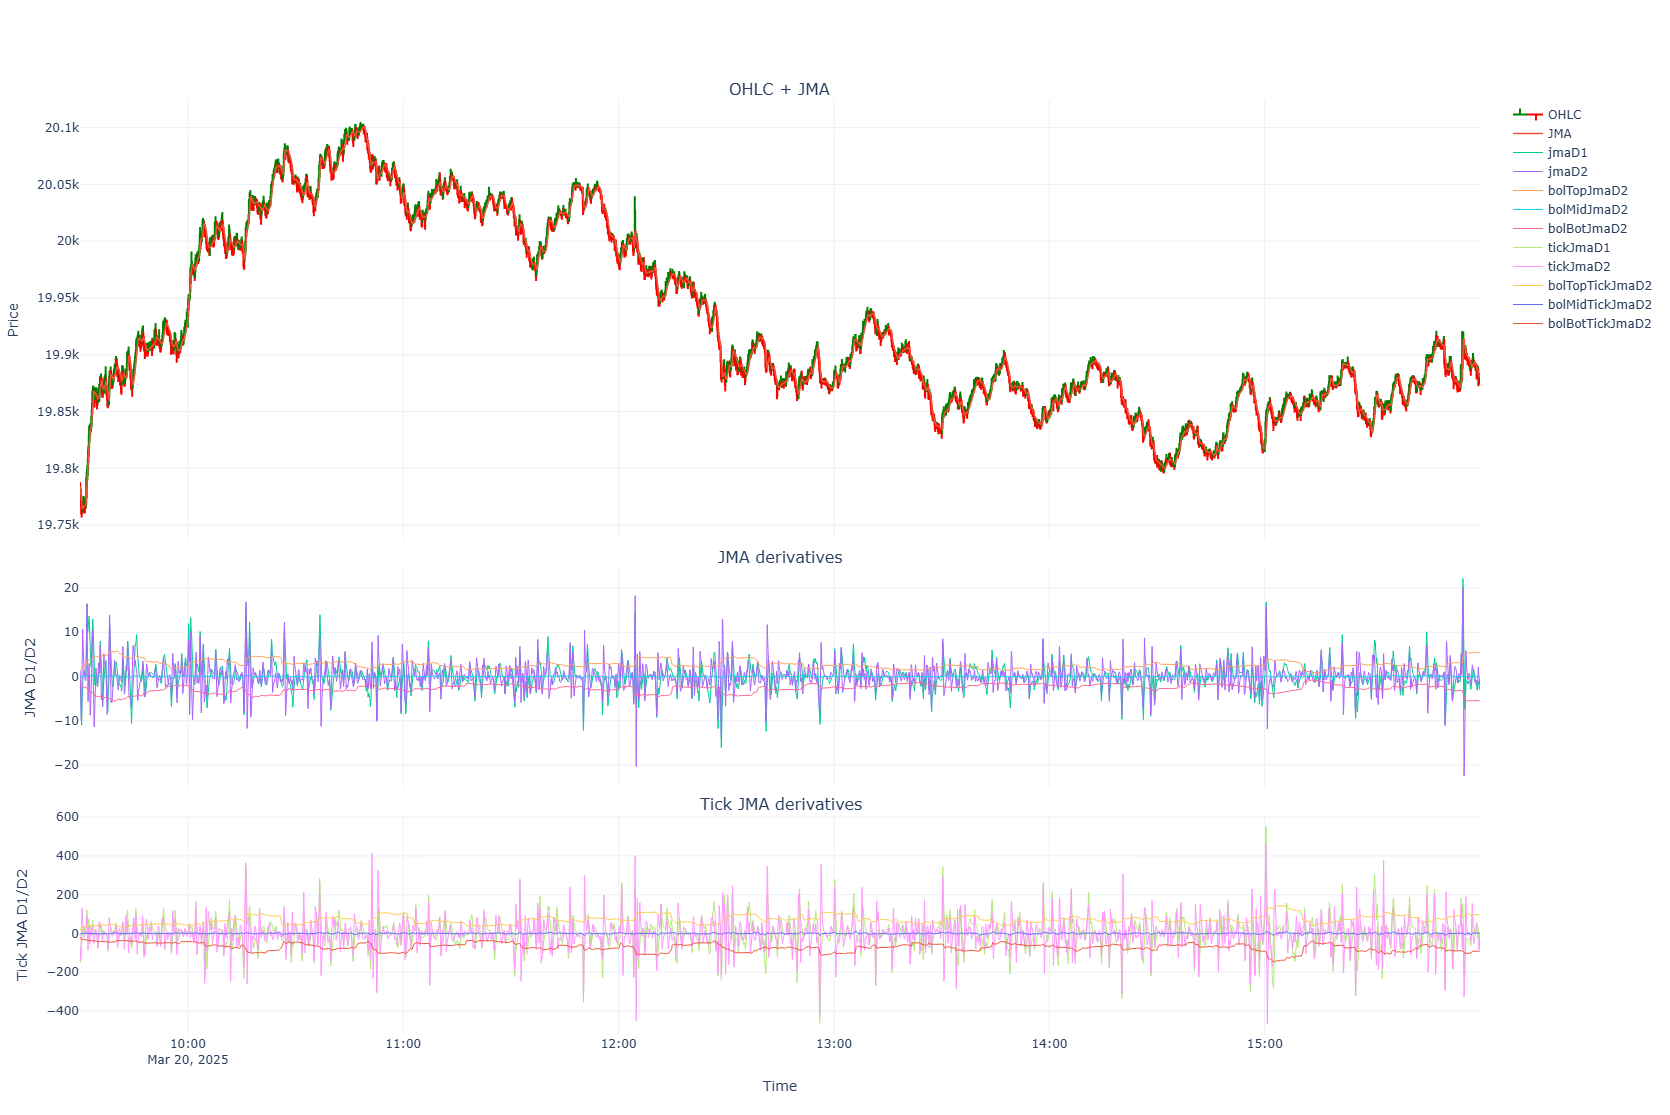

In [10]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def plot_day(df):
    d = df.sort_values("timestamp")

    fig = make_subplots(
        rows=3,
        cols=1,
        shared_xaxes=True,
        vertical_spacing=0.03,
        row_heights=[0.50, 0.25, 0.25],
        subplot_titles=[
            "OHLC + JMA",
            "JMA derivatives",
            "Tick JMA derivatives",
        ],
    )

    x = d["timestamp"]

    # Pane 1: OHLC bars
    fig.add_trace(
        go.Ohlc(
            x=x,
            open=d["Open"],
            high=d["High"],
            low=d["Low"],
            close=d["Last"],
            name="OHLC",
            increasing_line_color="green",
            decreasing_line_color="red",
        ),
        row=1,
        col=1,
    )

    # Pane 1: JMA overlay
    fig.add_trace(
        go.Scatter(
            x=x,
            y=d["JMA"],
            mode="lines",
            name="JMA",
            line=dict(width=1.5),
        ),
        row=1,
        col=1,
    )

    # Pane 2
    pane2_cols = [
        "jmaD1",
        "jmaD2",
        "bolTopJmaD2",
        "bolMidJmaD2",
        "bolBotJmaD2",
    ]

    for col in pane2_cols:
        fig.add_trace(
            go.Scatter(
                x=x,
                y=d[col],
                mode="lines",
                name=col,
                line=dict(width=1),
            ),
            row=2,
            col=1,
        )

    # Pane 3
    pane3_cols = [
        "tickJmaD1",
        "tickJmaD2",
        "bolTopTickJmaD2",
        "bolMidTickJmaD2",
        "bolBotTickJmaD2",
    ]

    for col in pane3_cols:
        fig.add_trace(
            go.Scatter(
                x=x,
                y=d[col],
                mode="lines",
                name=col,
                line=dict(width=1),
            ),
            row=3,
            col=1,
        )

    fig.update_layout(
        height=1100,
        width=2400,
        template="plotly_white",
        hovermode="x unified",
        showlegend=True,
        xaxis_rangeslider_visible=False,
    )

    fig.update_yaxes(title_text="Price", row=1, col=1)
    fig.update_yaxes(title_text="JMA D1/D2", row=2, col=1)
    fig.update_yaxes(title_text="Tick JMA D1/D2", row=3, col=1)

    fig.update_xaxes(title_text="Time", row=3, col=1)

    fig.show()

_day = '2025-03-20'
rawFile= f'data/mnq-tick-oscillator-6sec.pqt'
_raw = pd.read_parquet(rawFile)
_raw = _raw[_raw["timestamp"].dt.date == pd.Timestamp(_day).date()]
plot_day(_raw)

In [11]:
from sklearn.isotonic import IsotonicRegression
p_tr = bundle["model"].predict_proba(Xtr)[:, 1]
iso = IsotonicRegression(out_of_bounds="clip").fit(p_tr, ytr)
pred["p_cal"] = iso.predict(pred.p.to_numpy())

pred.to_parquet(f"{OUT_DIR}/pred-iso-calibrated-{HORIZON}h.parquet")

In [12]:
print(log_loss(y, pred.p_cal))                       # should shave a little off 0.30468
pred.assign(bin=pd.qcut(pred.p_cal, 10)).groupby("bin", observed=True).agg(
    mean_p=("p_cal", "mean"), realized=("is_target", "mean"), n=("p_cal", "size"))   # ends on diagonal now

0.3020596206188202


,mean_p,realized,n
bin,,,
"(-0.001, 0.0295]",0.023893,0.023320,151800
"(0.0295, 0.037]",0.035428,0.035907,206866
"(0.037, 0.0371]",0.037140,0.036985,141380
"(0.0371, 0.0406]",0.040099,0.040078,130422
"(0.0406, 0.0608]",0.049629,0.050050,118302
"(0.0608, 0.137]",0.100578,0.104025,149502
"(0.137, 0.175]",0.166589,0.166445,182174
"(0.175, 0.189]",0.182708,0.181414,113723
"(0.189, 0.202]",0.195970,0.195054,169092


In [13]:
nxt = pred.set_index("bar_index").p_cal
day = bars[bars.date.astype(str) == "2025-03-05"].copy()
day["hazard_next"] = nxt.reindex(day.bar_index + 1).to_numpy()   # NaN on last bar of day

In [14]:
# ? day.hazard_next ?

In [15]:
#

In [16]:
def label_within(fz, H, date_from=None, date_to=None):
    ys = []
    for S in fz._selected(date_from, date_to):
        t = np.nonzero(~S["warm"])[0]
        c = np.concatenate(([0], np.cumsum(S["tgt"].astype(np.int64))))
        hi = np.minimum(t + H, S["n"] - 1)
        ys.append((c[hi + 1] - c[t + 1]) > 0)
    return np.concatenate(ys)

yH_tr = label_within(fz, HORIZON, None, "2024-12-31")
yH_te = label_within(fz, HORIZON, "2025-01-01", None)
mH = LogisticRegression(C=100.0, solver="lbfgs", max_iter=2000).fit(Xtr, yH_tr)
pH = mH.predict_proba(Xte)[:, 1]

#pred = predict_hawkes(fz, bundle, start="2025-01-01", out_file=f"{OUT_DIR}/meta.parquet")          # bar_index, timestamp, is_target, p
_, _, meta_te = fz.build("2025-01-01", None)

sel = np.isin(meta_te["bar_index"].to_numpy(), at)        # meta_te from fz.build holdout
dfH = pd.DataFrame({"p": pH[sel], "y": yH_te[sel]})
dfH.assign(bin=pd.qcut(dfH.p, 10)).groupby("bin", observed=True).agg(
    pred=("p", "mean"), realized=("y", "mean"), n=("p", "size"))

,pred,realized,n
bin,,,
"(0.492, 0.6]",0.584505,0.639194,49977
"(0.6, 0.613]",0.607167,0.654621,49977
"(0.613, 0.622]",0.617366,0.664579,49976
"(0.622, 0.629]",0.625284,0.668888,49977
"(0.629, 0.636]",0.632329,0.673383,49976
"(0.636, 0.643]",0.639225,0.677758,49978
"(0.643, 0.651]",0.646574,0.682955,49974
"(0.651, 0.661]",0.655455,0.682374,49977
"(0.661, 0.678]",0.668732,0.692018,49977


In [17]:
def lag0_cols(fz, date_from=None, date_to=None):
    blocks = []
    for S in fz._selected(date_from, date_to):
        t = np.nonzero(~S["warm"])[0]
        blocks.append(np.stack([S["P"][c][t + 1] - S["P"][c][t] for c in fz.classes], 1))
    return np.concatenate(blocks).astype(np.float32)

XtrH = np.hstack([Xtr, lag0_cols(fz, None, "2024-12-31")])
XteH = np.hstack([Xte, lag0_cols(fz, "2025-01-01", None)])
mH = LogisticRegression(C=100.0, solver="lbfgs", max_iter=2000).fit(XtrH, yH_tr)
pH = mH.predict_proba(XteH)[:, 1]
# rebuild the decile table on sel as before (?)

sel = np.isin(meta_te["bar_index"].to_numpy(), at)        # meta_te from fz.build holdout
dfH = pd.DataFrame({"p": pH[sel], "y": yH_te[sel]})
dfH.assign(bin=pd.qcut(dfH.p, 10)).groupby("bin", observed=True).agg(
    pred=("p", "mean"), realized=("y", "mean"), n=("p", "size"))

,pred,realized,n
bin,,,
"(0.288, 0.593]",0.568888,0.591412,49977
"(0.593, 0.617]",0.605897,0.595486,49976
"(0.617, 0.638]",0.627477,0.609700,49977
"(0.638, 0.667]",0.651740,0.639927,49976
"(0.667, 0.691]",0.679923,0.713148,49977
"(0.691, 0.705]",0.698317,0.722867,49976
"(0.705, 0.716]",0.710785,0.717124,49976
"(0.716, 0.727]",0.721707,0.719391,49977
"(0.727, 0.74]",0.733359,0.725048,49976


In [18]:
pH_tr = mH.predict_proba(XtrH)[:, 1]
isoH = IsotonicRegression(out_of_bounds="clip").fit(pH_tr, yH_tr)
pH_cal = isoH.predict(pH)

pred["p_cal2"] = iso.predict(pred.p.to_numpy())

pred.to_parquet(f"{OUT_DIR}/pred-iso-calibrated2-{HORIZON}h.parquet")

In [19]:
print(log_loss(y, pred.p_cal))                       # should shave a little off 0.30468
pred.assign(bin=pd.qcut(pred.p_cal, 10)).groupby("bin", observed=True).agg(
    mean_p=("p_cal2", "mean"), realized=("is_target", "mean"), n=("p_cal2", "size"))   # ends on diagonal now

0.3020596206188202


,mean_p,realized,n
bin,,,
"(-0.001, 0.0295]",0.023893,0.023320,151800
"(0.0295, 0.037]",0.035428,0.035907,206866
"(0.037, 0.0371]",0.037140,0.036985,141380
"(0.0371, 0.0406]",0.040099,0.040078,130422
"(0.0406, 0.0608]",0.049629,0.050050,118302
"(0.0608, 0.137]",0.100578,0.104025,149502
"(0.137, 0.175]",0.166589,0.166445,182174
"(0.175, 0.189]",0.182708,0.181414,113723
"(0.189, 0.202]",0.195970,0.195054,169092


In [20]:
H_FROZEN = 3
frozen = pcont_hawkes(fz, bundle, at, horizon=HORIZON,out_file=f"{OUT_DIR}/pred-frozen-{H_FROZEN}h.parquet")

In [21]:
frozen

,bar_index,timestamp,pcont,h_used,pbreak,H
0,2969829,2025-01-02 09:31:12,0.467317,8,0.532683,8
1,2969830,2025-01-02 09:31:18,0.214562,8,0.785438,8
2,2969832,2025-01-02 09:31:30,0.505767,8,0.494233,8
3,2969833,2025-01-02 09:31:36,0.237477,8,0.762523,8
4,2969835,2025-01-02 09:31:48,0.277387,8,0.722613,8
...,...,...,...,...,...,...
499760,4461875,2026-07-08 15:58:42,0.537619,8,0.462381,8
499761,4461876,2026-07-08 15:58:48,0.260307,8,0.739693,8
499762,4461877,2026-07-08 15:58:54,0.229328,8,0.770672,8
499763,4461880,2026-07-08 15:59:12,0.582233,7,0.417767,8
